## Evualuacion de los modelos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import balanced_accuracy_score, classification_report, roc_auc_score, roc_curve
from utils.model_utils import load_multiple_models
from constants import (
    predicted_dir, 
    X_val, X_val_scaled, 
    y_val, y_val_scaled,
    X_test, X_test_scaled
)
import os

Cargamos los modelos

In [2]:
model_names = ["rf1", "rf2", "rf3", "rf4", "rf5", "rf6", "lr1", "lr2"]
models = load_multiple_models(model_names)

Procedemos a evaular los modelos con balanced_accuracy_score

In [3]:
X_dict = {
    # Original data models
    "rf1": X_val, 
    "rf2": X_val, 
    "rf3": X_val,
    "lr1": X_val,
    # Scaled data models  
    "rf4": X_val_scaled,
    "rf5": X_val_scaled, 
    "rf6": X_val_scaled,
    "lr2": X_val_scaled
}

In [4]:
y_dict = {
    # Original data models
    "rf1": y_val,
    "rf2": y_val,
    "rf3": y_val,
    "lr1": y_val,
    # Scaled data models
    "rf4": y_val_scaled,
    "rf5": y_val_scaled,
    "rf6": y_val_scaled,
    "lr2": y_val_scaled
}

evualamos los modelos originales (datos no normalizados)

In [5]:
results = {}
for name, model in models.items():
    print(f"\nEvaluating {name}:")
    print("-" * 50)
    
    X_eval = X_dict[name]
    y_eval = y_dict[name]
    
    # Make predictions
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1] if hasattr(model, "predict_proba") else None
    
    # Calculate metrics
    bal_acc = balanced_accuracy_score(y_eval, y_pred)
    auc = roc_auc_score(y_eval, y_proba) if y_proba is not None else None
    
    print(f"Balanced Accuracy: {bal_acc:.4f}")
    if auc is not None:
        print(f"AUC: {auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_eval, y_pred))
    
    results[name] = {
        "balanced_accuracy": bal_acc,
        "auc": auc,
        "classification_report": classification_report(y_eval, y_pred)
    }


Evaluating rf1:
--------------------------------------------------
Balanced Accuracy: 0.8607
AUC: 0.9769

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     38059
           1       0.94      0.72      0.82      1223

    accuracy                           0.99     39282
   macro avg       0.97      0.86      0.91     39282
weighted avg       0.99      0.99      0.99     39282


Evaluating rf2:
--------------------------------------------------
Balanced Accuracy: 0.8940
AUC: 0.9555

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     38059
           1       0.62      0.80      0.70      1223

    accuracy                           0.98     39282
   macro avg       0.81      0.89      0.85     39282
weighted avg       0.98      0.98      0.98     39282


Evaluating rf3:
--------------------------------------------------
Balanced Accuracy:

Calculamos el mejor modelo

In [6]:
best_acc = 0
best_model_name = None

for model_name, metrics in results.items():
    curr_acc = metrics["balanced_accuracy"]
    if curr_acc > best_acc:
        best_acc = curr_acc
        best_model_name = model_name

print(f"\nBest Model Overall: {best_model_name}")
print(f"Best Balanced Accuracy: {best_acc:.4f}")


Best Model Overall: rf2
Best Balanced Accuracy: 0.8940


Generamos las predicciones con el mejor modelo

In [7]:
best_model = models[best_model_name]
# Use appropriate test data based on model type
X_test_final = X_test_scaled if best_model_name in ["rf4", "rf5", "rf6", "lr2"] else X_test

# Make predictions
y_test_pred = best_model.predict(X_test_final)

# Save predictions
os.makedirs(predicted_dir, exist_ok=True)
pd.DataFrame(y_test_pred, columns=['predicted']).to_csv(
    f"{predicted_dir}/vehiculos_test_preds.csv", 
    index=False
)

print(f"\nPredictions saved to: {predicted_dir}/vehiculos_test_preds.csv")
print(f"Fraudulent transactions: {y_test_pred.sum()}")


Predictions saved to: ./datos/6. predichos/vehiculos_test_preds.csv
Fraudulent transactions: 862


Dibujamos la curva ROC para todos los modelos

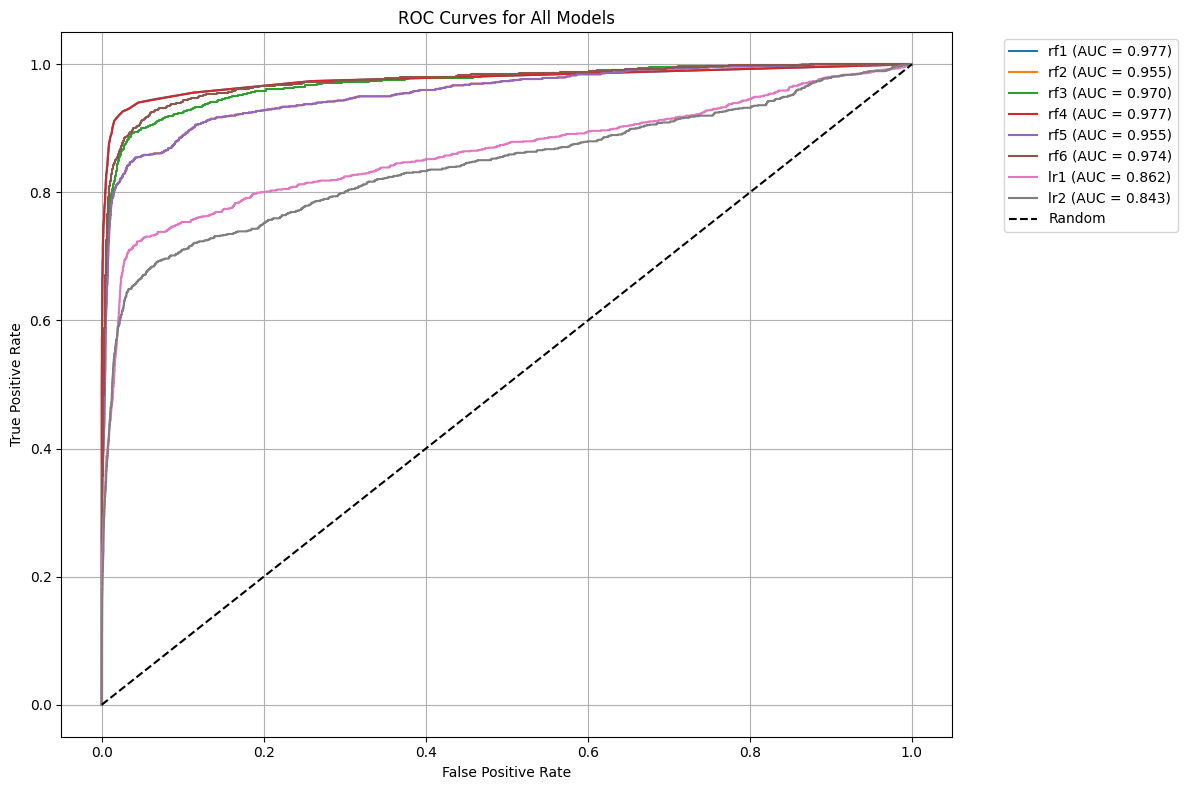

In [8]:
plt.figure(figsize=(12, 8))
for name, model in models.items():
    X_eval = X_dict[name]
    y_eval = y_dict[name]
    y_proba = model.predict_proba(X_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y_eval, y_proba)
    auc = results[name]["auc"]
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

Hasta el momento el modelo rf3 (modelo que no usa datos escalados) nos ha resultado el mejor modelo segun la metrica de *balanced_accuracy_score*. Aunque en otras iteraciones ha ganado rf6, el maximo alcanzado ha sido inferior al actual.

In [9]:
print("\nModel Comparison Summary:")
print("=" * 80)
comparison_data = []
for name in model_names:
    comparison_data.append({
        'Model': name,
        'Balanced Accuracy': f"{results[name]['balanced_accuracy']:.4f}",
        'AUC': f"{results[name]['auc']:.4f}",
        'Data Type': 'Scaled' if name in ["rf4", "rf5", "rf6", "lr2"] else 'Original'
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))


Model Comparison Summary:
Model Balanced Accuracy    AUC Data Type
  rf1            0.8607 0.9769  Original
  rf2            0.8940 0.9555  Original
  rf3            0.8914 0.9703  Original
  rf4            0.8611 0.9769    Scaled
  rf5            0.8940 0.9555    Scaled
  rf6            0.8940 0.9741    Scaled
  lr1            0.8228 0.8623  Original
  lr2            0.8031 0.8428    Scaled
